# Questão 1 — Candidato a tumor via morfologia matemática

Pipeline: leitura → escala de cinza → filtro passa-baixas → filtro de mediana → histograma/Otsu → binarização → abertura/fechamento → componentes conexos → maior componente.

In [2]:
import sys
sys.path.append("..")

from core import io_utils, filters, binarization, morphology, visualization

CAMINHO_ENTRADA = "../data/input/brain.jpg"
CAMINHO_SAIDA = "../data/output/q1"

### Carregar a imagem e converter para a escala de cinza

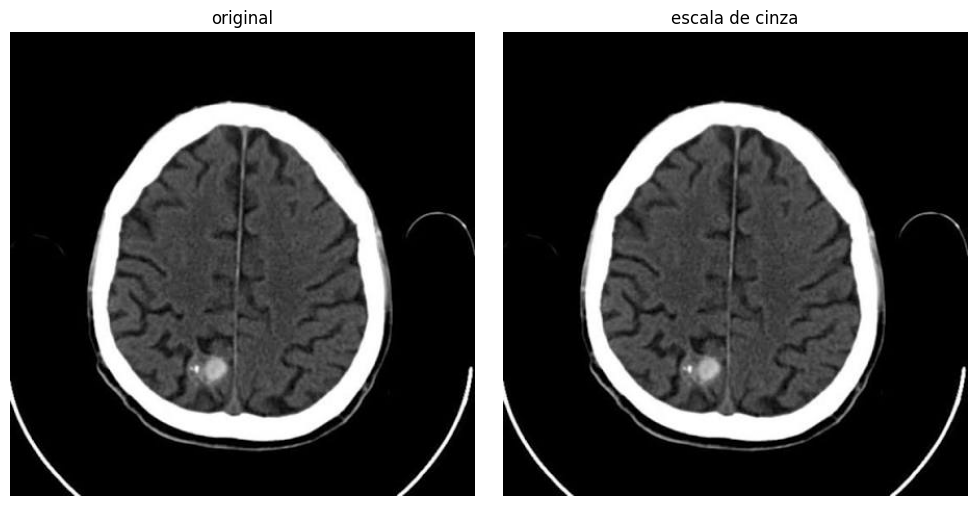

In [3]:
img = io_utils.carregar_imagem(CAMINHO_ENTRADA)
img_cinza = io_utils.para_escala_cinza(img)
visualization.mostrar_lado_a_lado([img, img_cinza], ["original", "escala de cinza"])

### Filtro passa-baixas + filtro de mediana (remoção de ruído)

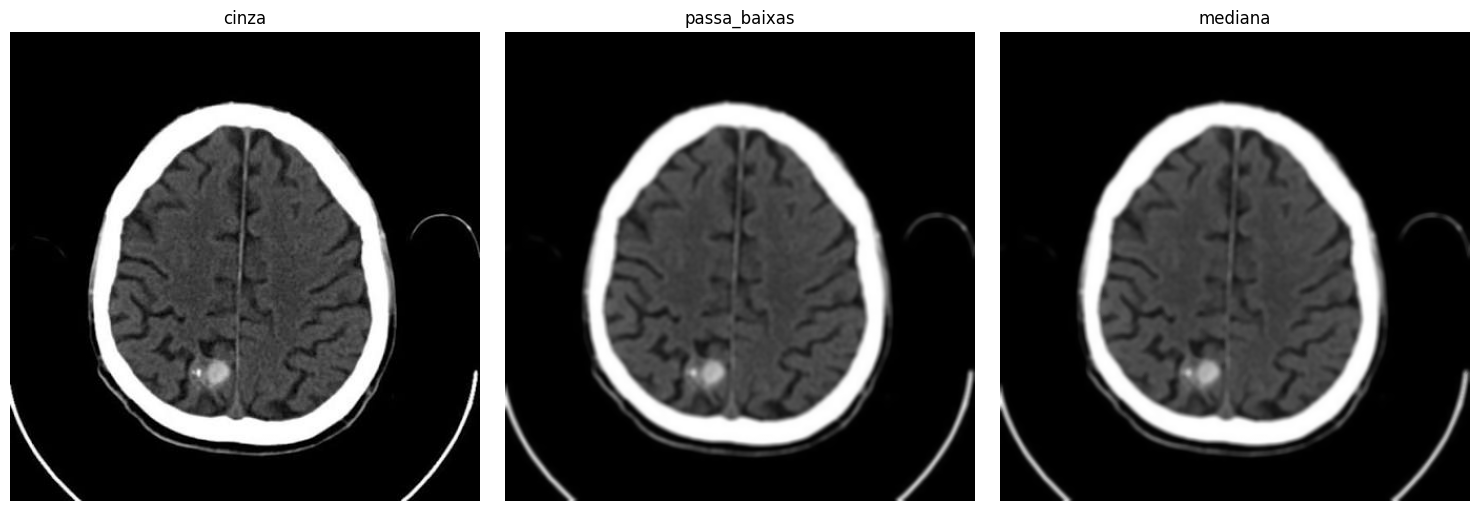

In [4]:
suave = filters.filtro_passa_baixas(img_cinza, tamanho_kernel=5)
sem_ruido = filters.filtro_mediana(suave, tamanho_kernel=3)
visualization.mostrar_lado_a_lado([img_cinza, suave, sem_ruido], ["cinza", "passa_baixas", "mediana"])

### Histograma e Escolha do Limiar (Otsu)

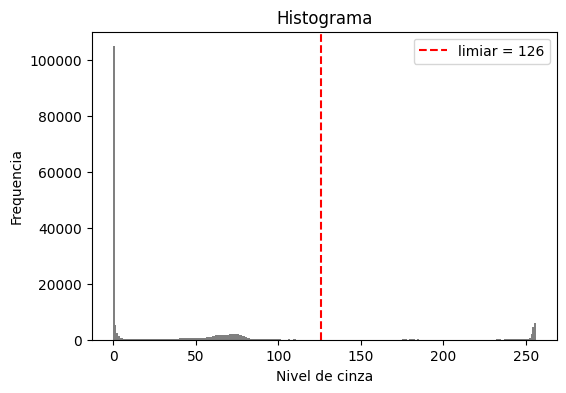

Limiar escolhido:  126


In [5]:
limiar = binarization.encontrar_limiar_otsu(sem_ruido)
visualization.mostrar_histograma(sem_ruido, limiar=limiar)
print("Limiar escolhido: ", limiar)

### Binarização

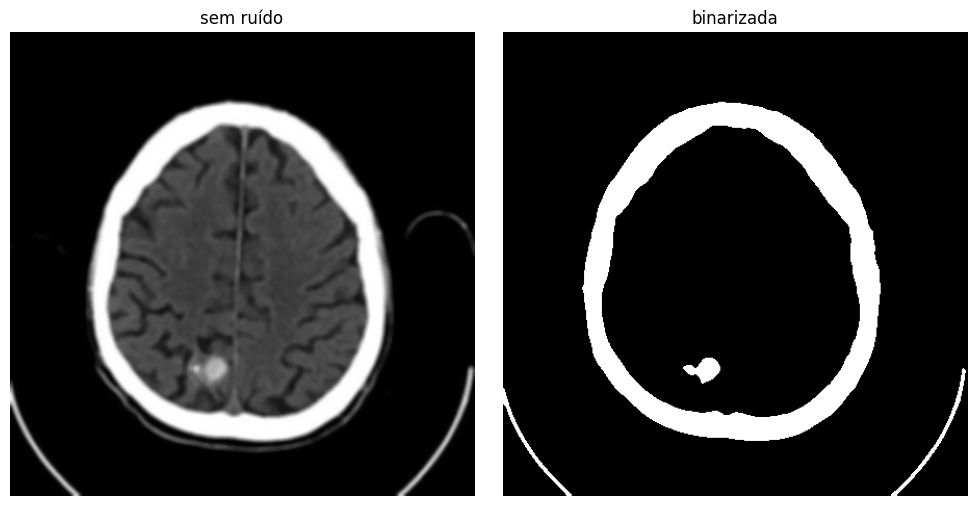

In [10]:
img_bin = binarization.binarizar(sem_ruido, limiar)
visualization.mostrar_lado_a_lado([sem_ruido, img_bin], ["sem ruído", "binarizada"])

### Abertura e Fechamento

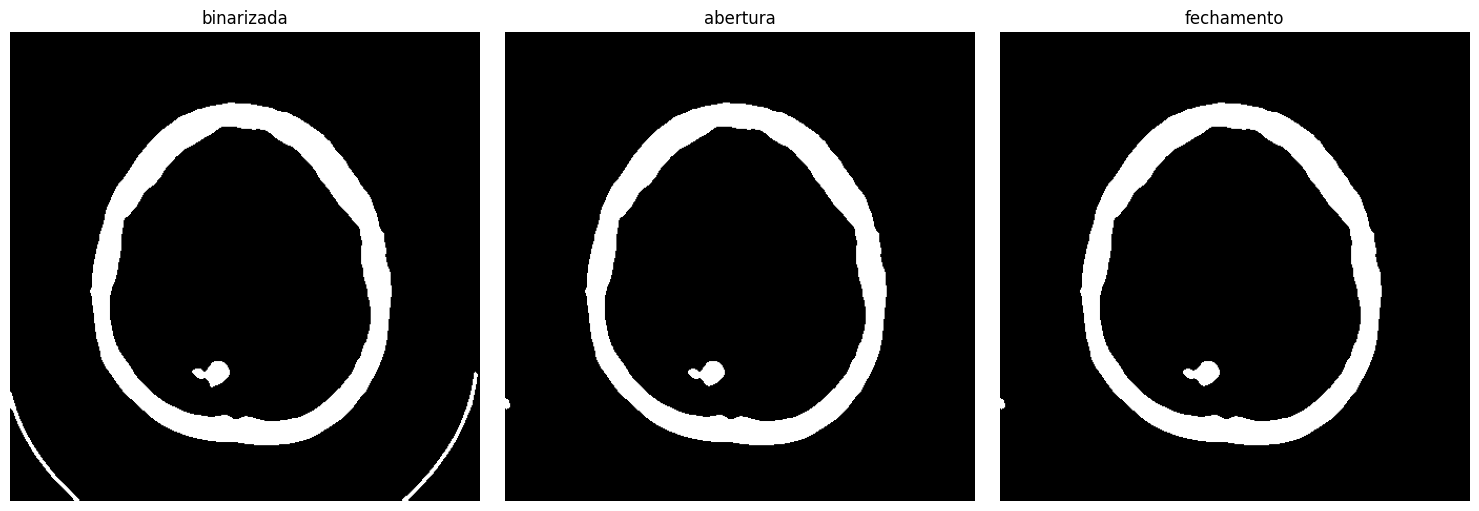

In [15]:
aberta = morphology.abertura(img_bin, tamanho_kernel=7)
fechada = morphology.fechamento(aberta, tamanho_kernel=7)
visualization.mostrar_lado_a_lado([img_bin, aberta, fechada], ["binarizada", "abertura", "fechamento"])

### Compontes conexos e maior elemento (candidato ao tumor)

Testamos primeiro selecionar pela maior área e descobrimos que isso pega o crânio (estrutura grande e fina, área ~10% da imagem), não o tumor.
Por isso o critério final usa **compacidade** (área / área-da-bounding-box): o tumor é um blob preenchido, enquanto o crânio e artefatos da mesa do tomógrafo são estruturas finas e alongadas.

In [8]:
labels, stats = morphology.elementos_conexos(fechada)

#tabela de diagnóstico -- área vs compacidade de cada componente

for i in range(1, len(stats)):
    x, y, w, h, area = stats[i]
    print(f"componente {i}: area={area:5d}  bbox=({w}x{h})  compacidade={area / (w * h):.2f}")

componente 1: area=20561  bbox=(286x326)  compacidade=0.22
componente 2: area=  384  bbox=(23x23)  compacidade=0.73


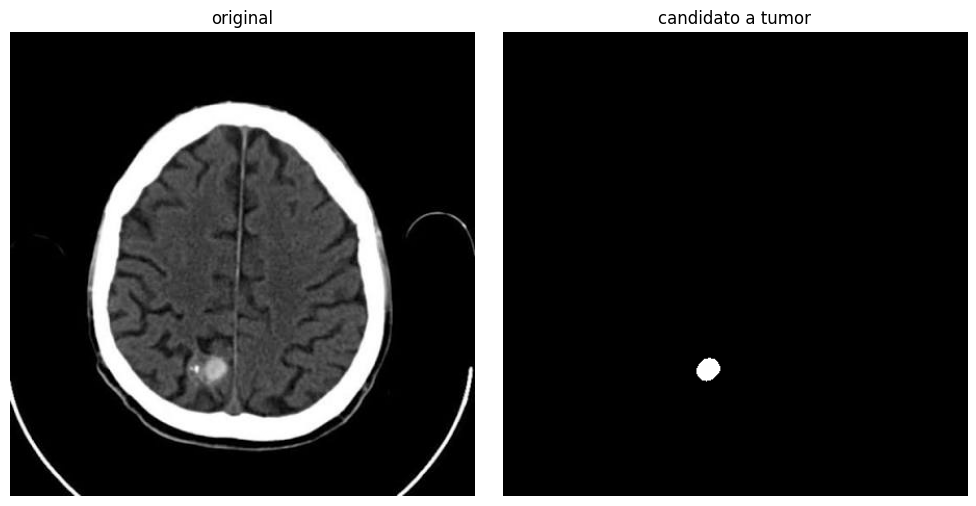

In [9]:
mascara_tumor = morphology.maior_componente(labels, stats)
visualization.mostrar_lado_a_lado([img_cinza, mascara_tumor], ["original", "candidato a tumor"])
io_utils.salvar_imagem(f"{CAMINHO_SAIDA}/candidato_tumor.png", mascara_tumor)